# Pan-Tompkins Algorithm — Offline QRS Detection

The Pan–Tompkins algorithm is a classical QRS-complex detection algorithm originally designed for real-time ECG processing. Its main objective is to identify reliable R-peak locations from an ECG signal.

In this project, the algorithm is reconstructed and implemented step by step rather than using an existing ECG/QRS detection library. Each processing stage is first studied theoretically, then implemented, visualized, inspected, and finally integrated into a complete detector.

## Offline Adaptation

The original Pan–Tompkins algorithm was designed for continuous, real-time ECG processing. Since the current development environment uses previously recorded ECG signals, this notebook implements an **offline adaptation** of the detection framework.

Instead of processing newly acquired samples sequentially in real time, the complete recorded signal is available in advance. This allows the detection stages to operate on the recorded signal and its previously detected candidates.

This offline implementation is intended as an engineering and experimental reconstruction of the Pan–Tompkins detection framework. It should therefore not be considered an exact reproduction of the original real-time implementation.

The offline detector is designed to:

- process already recorded ECG samples,
- identify candidate peaks,
- adaptively classify signal and noise peaks,
- apply a refractory period,
- recover potentially missed beats using search-back,
- localize the R-peaks on the filtered ECG signal,
- and provide the final R-peak locations for subsequent ECG analysis.

## Detection Pipeline

The implemented offline processing chain is:

ECG
→ Band-pass Filtering
→ Derivative
→ Squaring
→ Moving-Window Integration
→ Local Peak Detection
→ Adaptive Thresholding
→ Refractory Period
→ Search-back
→ R-peak Localization

The integrated signal is primarily used for QRS candidate detection and adaptive decision-making, while the filtered ECG signal is used during the final R-peak localization stage to obtain physiologically meaningful R-peak positions.

## Final Output

The primary output of the offline detector is the set of detected **R-peak sample indices**.

These locations can subsequently be used for:

- heart-rate estimation,
- RR-interval extraction,
- HRV-related analysis,
- beat-to-beat analysis,
- and extraction of additional ECG features.

The implementation will be evaluated against the reference annotations provided with the MIT-BIH Arrhythmia Database to assess detection performance and identify potential failure cases.

## 1. Setup and Development Data

In [2]:
# Import libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

# Define the project paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MITDB_DIR = RAW_DATA_DIR / "mit-bih-arrhythmia"


In [ ]:
# Get one record to be used for the development procedure
record_name = "100"
record = wfdb.rdrecord(str(MITDB_DIR / record_name))

signal = record.p_signal                    # The signal
fs = record.fs                              # Sampling frequency of the record
samples_number = record.sig_len             # Number of samples in the record
time = np.arange(samples_number) / fs       # Time Vector of the record

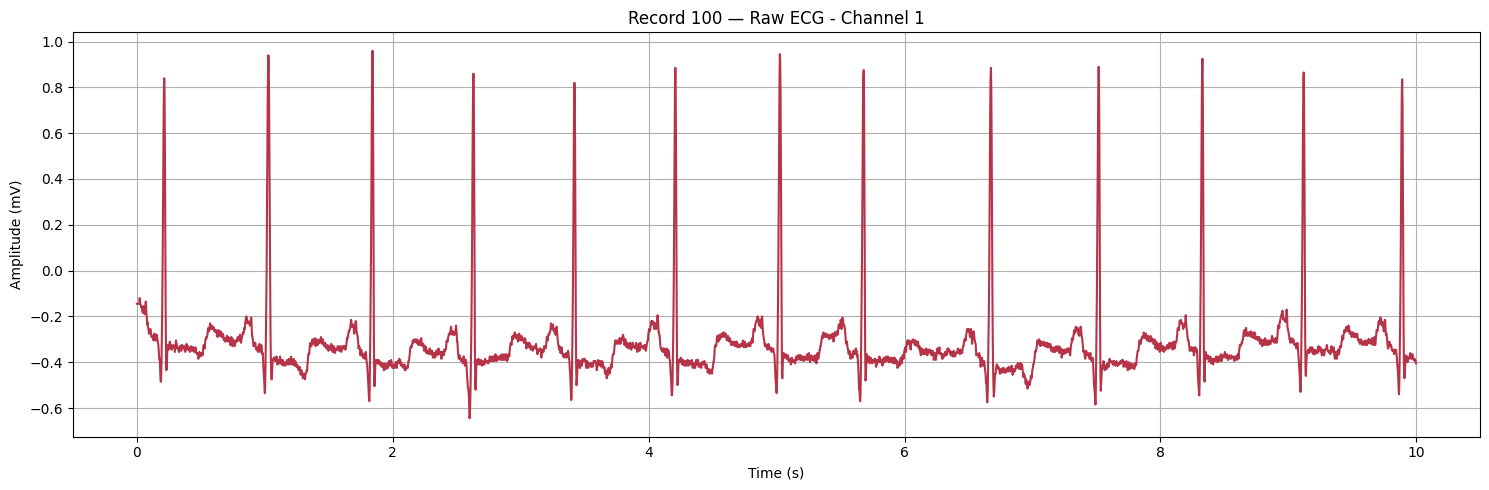

In [4]:
# Plot & Inspect

# Duration of the signal displayed in the plot
duration = 10
# Calculate the number of samples to plot --> N = T . Fs
n_samples_to_plot = int(duration * fs)
# 10 second signal
ten_seg_sig = signal[:n_samples_to_plot, 0]

# Visualize 
plt.figure(figsize=(15, 5))
plt.plot(time[:n_samples_to_plot], ten_seg_sig, color="#b73347")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Raw ECG - Channel 1")
plt.grid()
plt.tight_layout()
plt.show()

## 2. Resampling
> In case of using a different samoling frequency than the original one.

In [4]:
def resample_signal(signal, original_fs:float, target_fs:float=200):
    """
    Resample a discrete signal to a target sampling frequency using
    linear interpolation.

    Parameters
    ----------
    signal : array_like
        Input discrete-time signal.
    original_fs : float
        Sampling frequency of the input signal in Hz.
    target_fs : float, optional
        Desired sampling frequency in Hz. Default is 200 Hz.

    Returns
    -------
    resampled_signal : ndarray
        Signal resampled at the target sampling frequency.
    new_time : ndarray
        Time vector corresponding to the resampled signal, in seconds.
    """
    # Calculate original time vector
    original_time = np.arange(len(signal)) / original_fs
    # Calculate new length = new number of samples
    new_length = int(len(signal) * target_fs / original_fs )
    # Calculate new time vector considering the new length and target sampling frequency
    new_time = np.arange(new_length) / target_fs

    # Apply linear interpolation
    resampled_signal = np.interp(new_time, original_time, signal)

    return resampled_signal, new_time

## 3. Band-Pass Filter

In [ ]:
def band_pass_filter(signal):
    """
    Apply the recursive band-pass filter used in the Pan-Tompkins algorithm.

    The filter consists of a low-pass stage followed by a high-pass stage.
    Both stages are implemented using the recursive difference equations
    defined by the original Pan-Tompkins method.

    Parameters
    ----------
    signal : numpy.ndarray
        One-dimensional ECG signal to be filtered.

    Returns
    -------
    numpy.ndarray
        Band-pass filtered ECG signal.

    Notes
    -----
    The filter is implemented directly from its recursive difference
    equations rather than using a general-purpose digital filter design
    routine. The output is not amplitude-normalized.

    Band of frequencies: 5 - 15 Hz

    Mathematical statements: 

        Low-Pass: 
            y[n]= 2y[n−1] − y[n−2] + x[n] − 2x[n−6] + x[n−12]

        High-Pass:
            y[n]= 32x[n−16] − y[n−1] − x[n] + x[n−32]
    """

    # Low-pass stage
    # -----------------
    # Initialize low pass output --> also: [0.0] * len(signal)
    y_lp = np.zeros(len(signal))

    for sample in range(len(signal)):
        # Initialize y[n] = x[n]
        y_lp[sample] = signal[sample]

        # Apply 2y[n-1]
        if (sample >= 1):
            y_lp[sample] += 2 * y_lp[sample - 1]

        # Apply -y[n-2]
        if (sample >= 2):
            y_lp[sample] -= y_lp[sample - 2]

        # Apply -2x[n-6]
        if (sample >= 6):
            y_lp[sample] -= 2 * signal[sample - 6]

        # Apply x[n-12]
        if (sample >= 12):
            y_lp[sample] += signal[sample - 12]

    # High-pass stage
    # -----------------
    # Initialize high pass output
    y_hp = np.zeros(len(signal))
    
    for sample in range(len(signal)):
        # Initialize y[n] = -x[n]
        y_hp[sample] = -y_lp[sample] 

        # Apply 32x[n−16]
        if (sample >= 16):
            y_hp[sample] += 32 * y_lp[sample - 16]

        # Apply −y[n−1]
        if (sample >= 1):
            y_hp[sample] -= y_hp[sample - 1]

        # Apply x[n−32]
        if (sample >= 32):
            y_hp[sample] += y_lp[sample - 32]

    return y_hp


In [6]:
filtered_signal = band_pass_filter(ten_seg_sig)
filtered_signal

array([ 1.45000e-01,  2.90000e-01,  5.80000e-01, ..., -2.06410e+02,
       -2.08055e+02, -2.09285e+02], shape=(3600,))

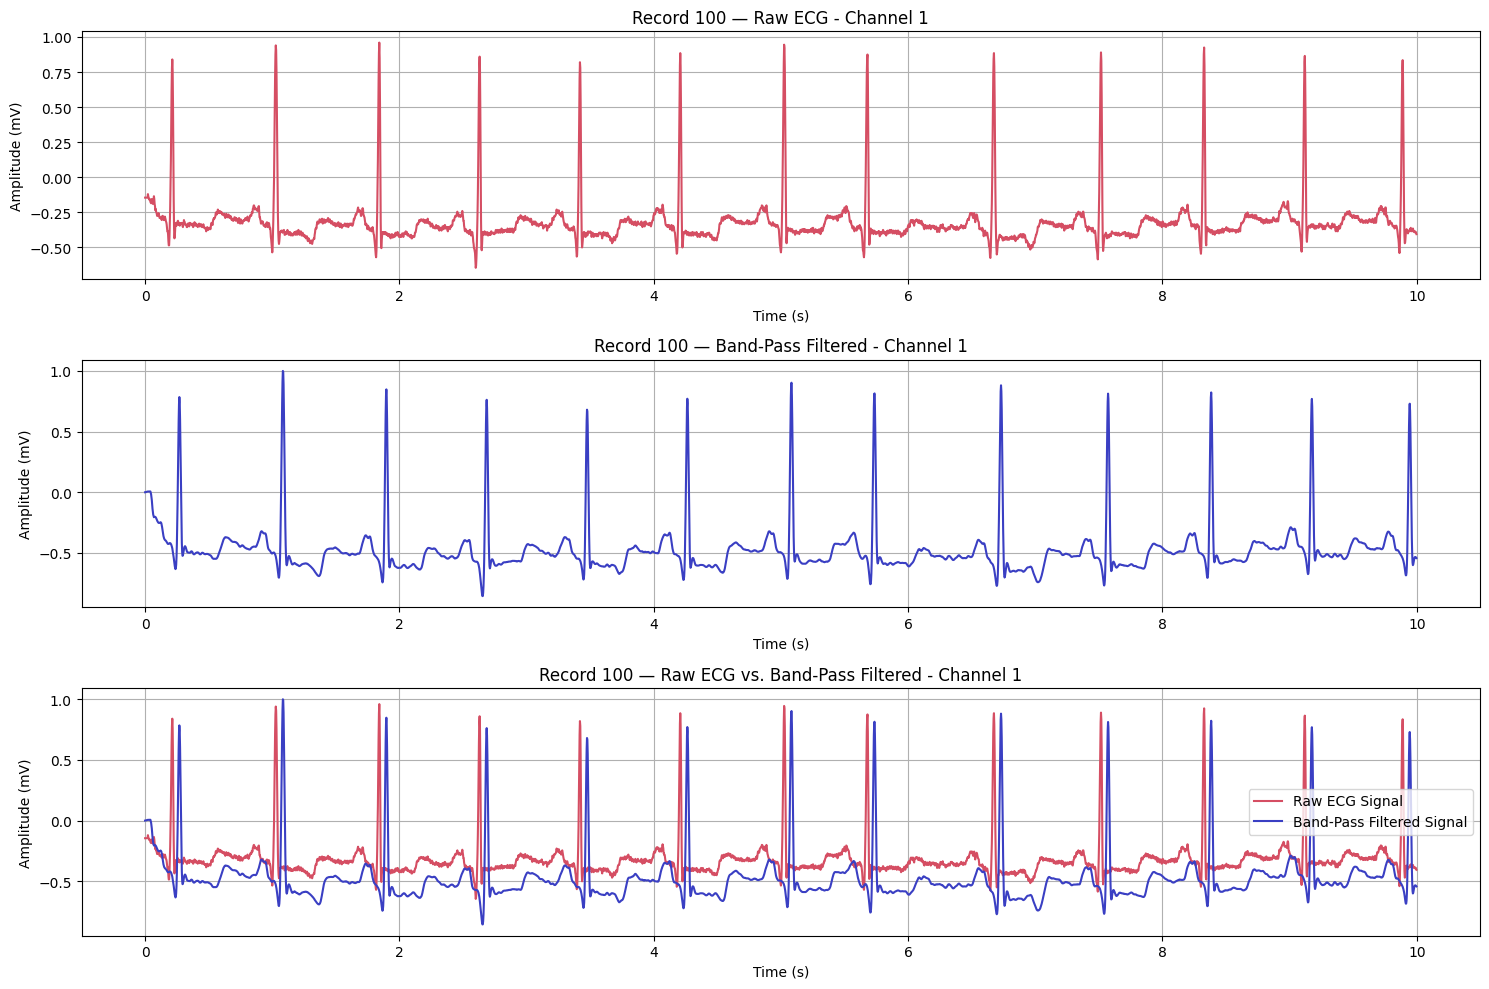

In [7]:
# Normalize for visualization
normalized_filtered = filtered_signal / np.max(np.abs(filtered_signal))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(time[:n_samples_to_plot], ten_seg_sig, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Raw ECG - Channel 1")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#3a3fc3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered - Channel 1")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time[:n_samples_to_plot], ten_seg_sig, color="#d54e63", label="Raw ECG Signal")
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#3a3fc3", label="Band-Pass Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Raw ECG vs. Band-Pass Filtered - Channel 1")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 4. Derivative

In [8]:
# y[n]=​(−x[n−2]−2x[n−1]+2x[n+1]+x[n+2])/8T

def derivative(signal, fs:float):
    """
    Apply the five-point derivative filter used in the Pan-Tompkins
    QRS detection algorithm.

    Parameters
    ----------
    signal : array_like
        Input ECG signal.
    fs : float
        Sampling frequency of the input signal in Hz.

    Returns
    -------
    derivative_signal : ndarray
        Derivative-filtered ECG signal.

    Notes
    -----
    The derivative is computed using the five-point finite-difference
    equation:

        y[n] = (-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2]) / (8T)

    where T = 1 / fs is the sampling period.

    The first and last two samples cannot be evaluated using the
    five-point formulation and are therefore left at zero.
    """
    
    # Compute T = 1 / Fs
    T = 1 / fs
    
    # Initialize output
    derivative_signal = np.zeros(len(signal))

    # Apply 5-point derivative 
    for sample in range(2, len(signal) - 2):

        derivative_signal[sample] = (
            - signal[sample - 2]
            - 2 * signal[sample - 1]
            + 2 * signal[sample + 1]
            + signal[sample + 2]
        )

        derivative_signal[sample] /= 8 * T

    return derivative_signal

In [9]:
derivative_signal = derivative(filtered_signal, fs)
derivative_signal

array([   0.  ,    0.  ,  104.4 , ..., -330.75,    0.  ,    0.  ],
      shape=(3600,))

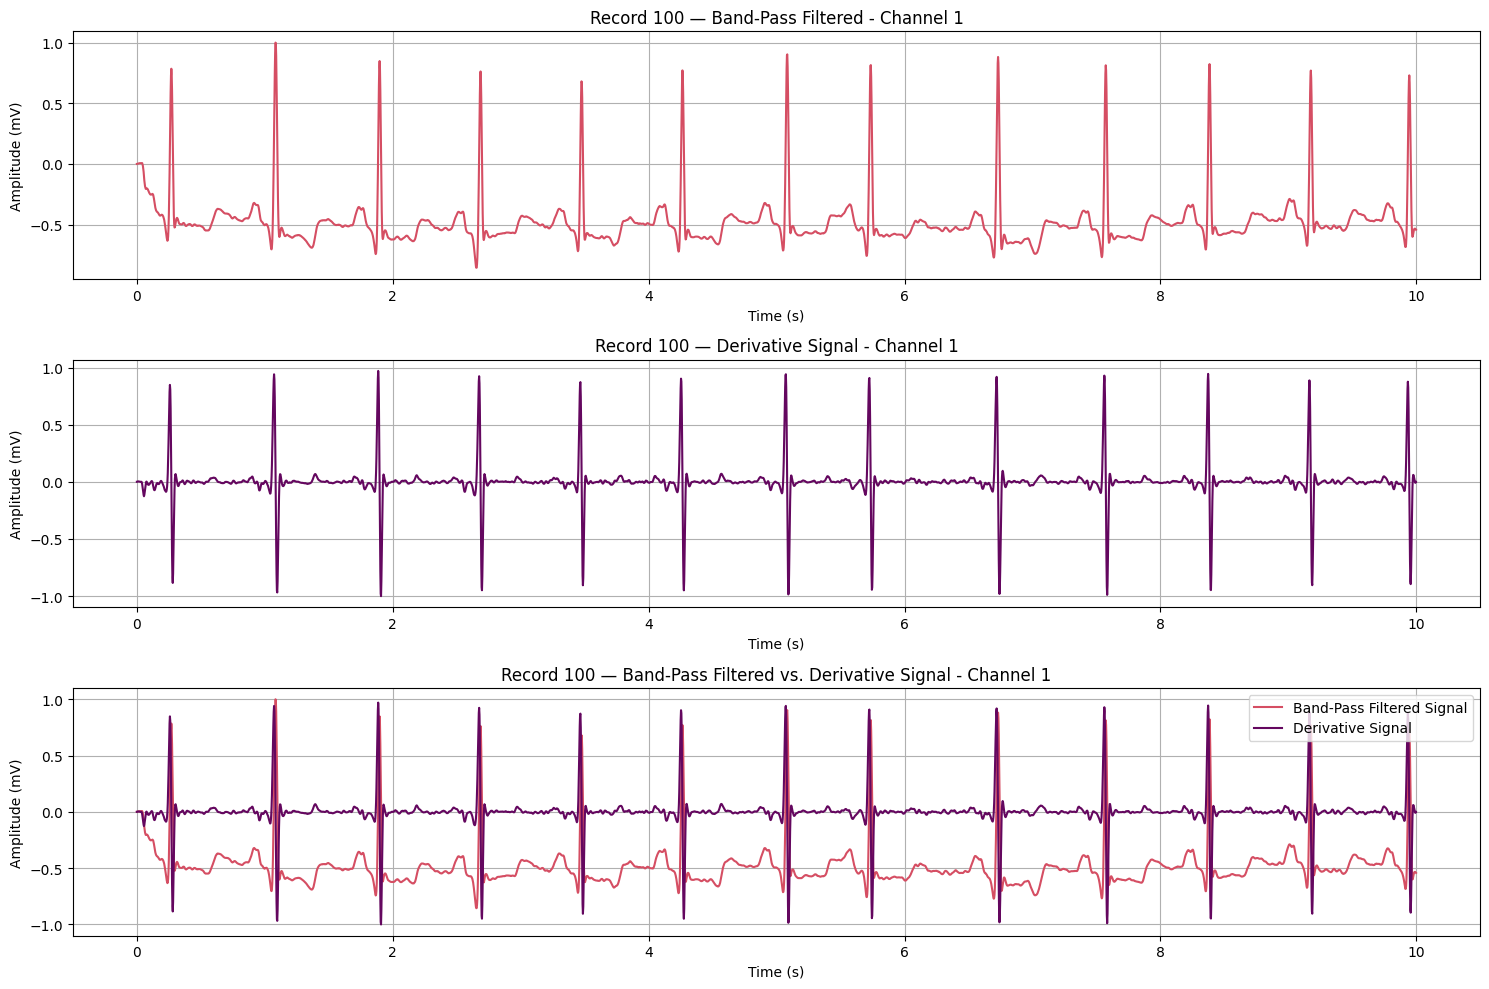

In [10]:
# Normalize for visualization
normalized_derivative = derivative_signal / np.max(np.abs(derivative_signal))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered - Channel 1")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_derivative, color="#64075f")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal - Channel 1")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#d54e63", label="Band-Pass Filtered Signal")
plt.plot(time[:n_samples_to_plot], normalized_derivative, color="#64075f", label="Derivative Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered vs. Derivative Signal - Channel 1")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 5. Square

In [11]:
def square(signal):
    """
    Square each sample of a discrete signal.

    Parameters
    ----------
    signal : array_like
        Input signal.

    Returns
    -------
    squared_signal : ndarray
        Signal after squaring each sample.
    """

    # Initialize output
    squared_signal = np.zeros(len(signal))

    # Apply squaring
    for sample in range(len(signal)):
        squared_signal[sample] = signal[sample] ** 2

    return squared_signal


In [12]:
squared_signal = square(derivative_signal)
squared_signal

array([     0.        ,      0.        ,  10899.36      , ...,
       109395.56249986,      0.        ,      0.        ], shape=(3600,))

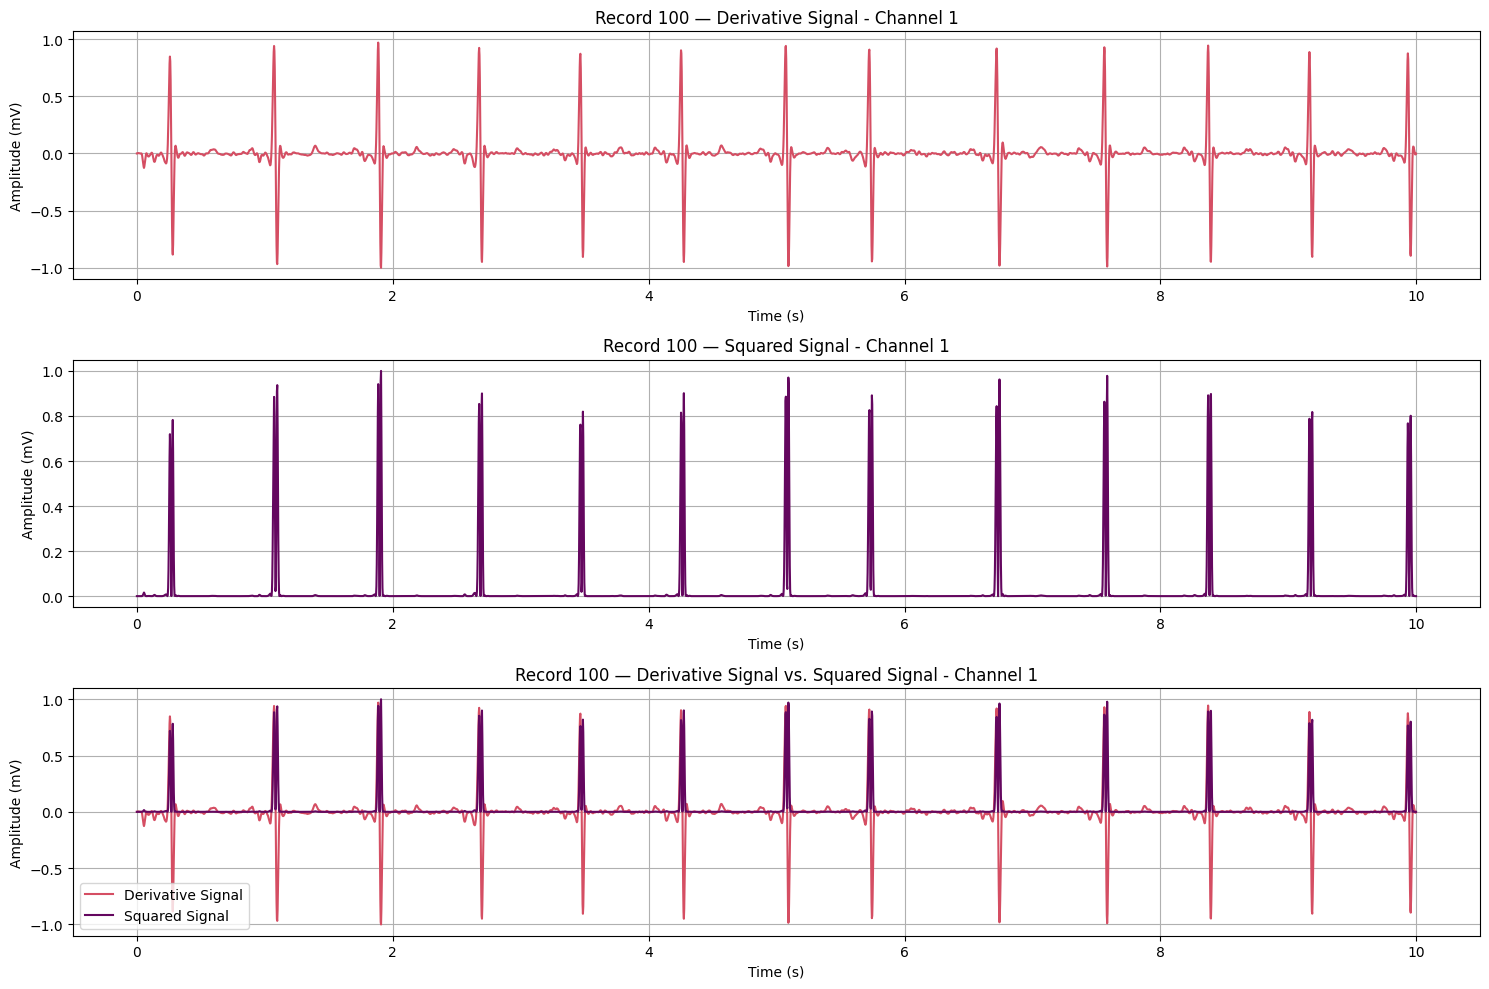

In [13]:
# Normalize for visualization
normalized_squared = squared_signal / np.max(np.abs(squared_signal))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_derivative, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal - Channel 1")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_squared, color="#64075f")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal - Channel 1")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time[:n_samples_to_plot], normalized_derivative, color="#d54e63", label="Derivative Signal")
plt.plot(time[:n_samples_to_plot], normalized_squared, color="#64075f", label="Squared Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal vs. Squared Signal - Channel 1")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 6. Moving-Window Integration (MWI)
The purpose of MWI is to combine the squared signal over a short time window, producing a smoother representation of the energy associated with the QRS complex.

In [14]:
def moving_window_integration(signal, fs, window_duration=0.15):
    """
    Apply a moving-window integration to a discrete signal.

    Parameters
    ----------
    signal : array_like
        Input signal, typically the squared output of the
        Pan-Tompkins derivative stage.
    fs : float
        Sampling frequency of the input signal in Hz.
    window_duration : float, optional
        Integration-window duration in seconds. Default is 0.15 s.

    Returns
    -------
    integrated_signal : ndarray
        Moving-window integrated signal.

    Notes
    -----
    The moving-window integration is computed as:

        y[n] = (1/N) * sum(x[n-i], i=0,...,N-1)

    where N is the number of samples in the integration window.
    Samples before the first complete window are left at zero.
    """

    # Calculate window size
    window_size = int(window_duration * fs)

    # Initialize output
    integrated_signal = np.zeros(len(signal))

    # Calculate the first complete window
    window_sum = np.sum(signal[:window_size])
    integrated_signal[window_size - 1] = window_sum / window_size

    # Move (slide) the window through the signal
    for sample in range(window_size, len(signal)):
        window_sum += signal[sample]
        window_sum -= signal[sample - window_size]

        integrated_signal[sample] = window_sum / window_size

    return integrated_signal


In [15]:
integrated_signal = moving_window_integration(squared_signal, fs)
integrated_signal

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
       1.67765284e+08, 1.67765214e+08, 1.67765184e+08], shape=(3600,))

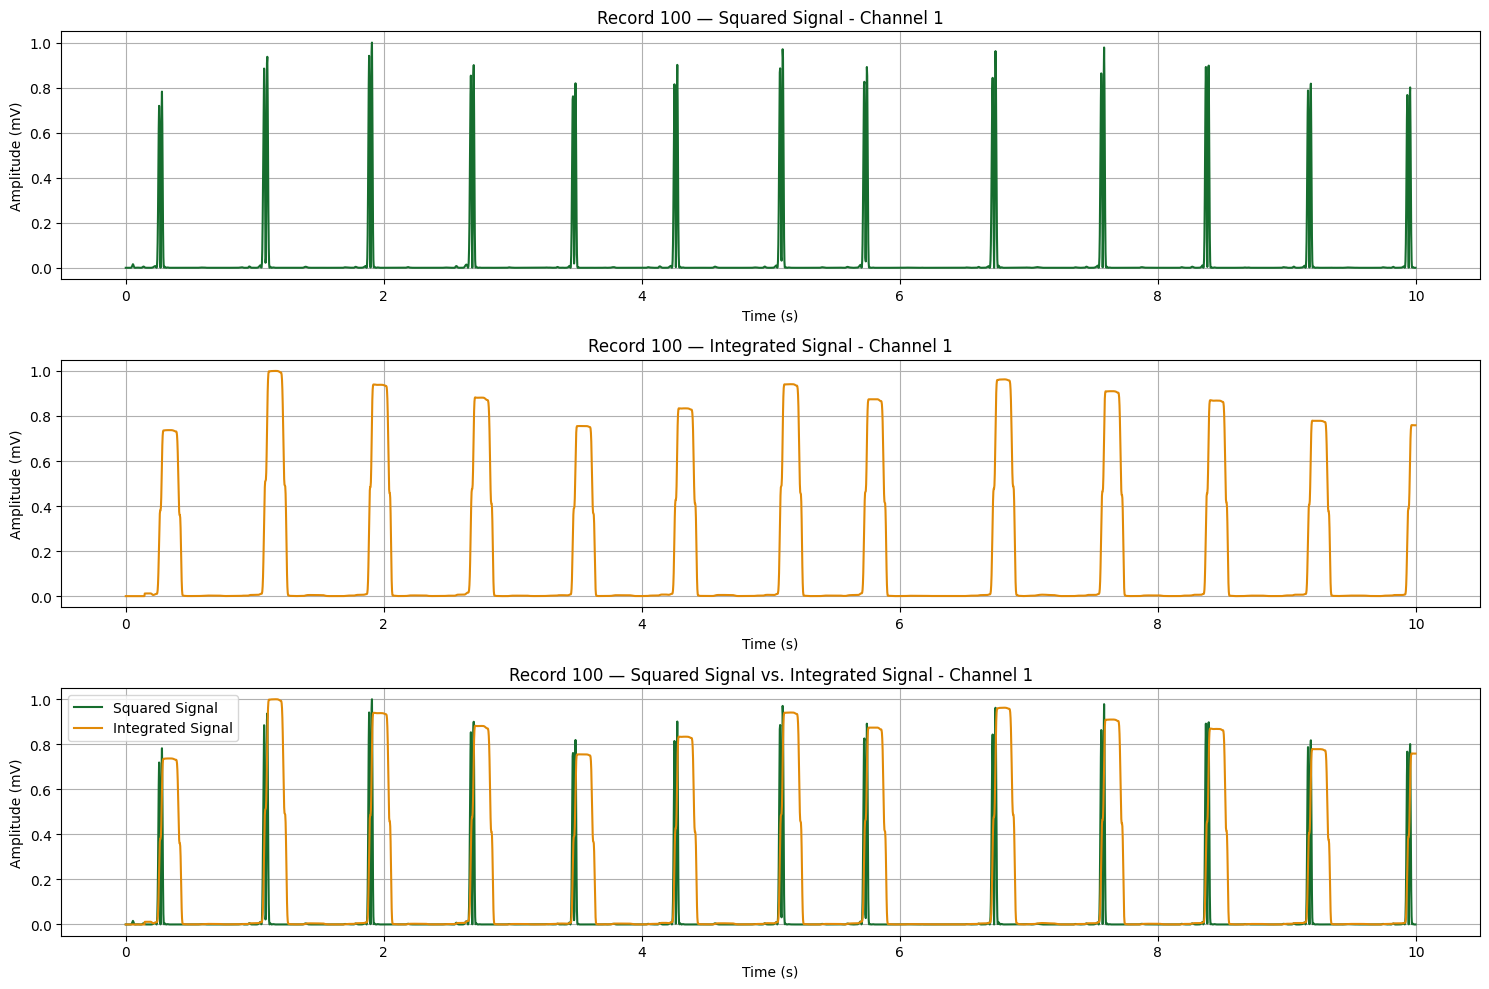

In [16]:
# Normalize for visualization
normalized_integrated = integrated_signal / np.max(np.abs(integrated_signal))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_squared, color="#166d2e")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal - Channel 1")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#e18a08")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal - Channel 1")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time[:n_samples_to_plot], normalized_squared, color="#166d2e", label="Squared Signal")
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#e18a08", label="Integrated Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal vs. Integrated Signal - Channel 1")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 7. Local Peaks Detection 

In [17]:
def detect_peaks(signal):
    """
    Detect local maxima in a one-dimensional signal.

    A sample is identified as a peak when its amplitude is greater than
    the preceding sample and greater than or equal to the following sample.

    Parameters
    ----------
    signal : array_like
        One-dimensional input signal in which local maxima are detected.

    Returns
    -------
    peaks : list
        Amplitudes of the detected local maxima.
    peaks_time : list
        Sample indices corresponding to the detected local maxima.

    Notes
    -----
    This method performs basic local-maximum detection without applying
    amplitude thresholds, a refractory period, or adaptive peak selection.
    These operations are handled by subsequent stages of the Pan-Tompkins
    algorithm.

    Mathematical statement: 
         x[n] > x[n−1] & x[n] ≥ x[n+1]
    """
    
    # Initialize lists to store peaks values 
    #   and their corresponding indices
    peaks = []
    peaks_indices = []

    # Apply the mathematical statement
    for sample in range(1, len(signal) - 1):
        if (
        signal[sample] > signal[sample - 1]
        and 
        signal[sample] >= signal[sample + 1]
        ):
            peaks.append(signal[sample]) 
            peaks_indices.append(sample)


    return peaks, peaks_indices


In [19]:
peaks_int, peaks_int_indices = detect_peaks(integrated_signal)
peaks_filt, peaks_filt_indices = detect_peaks(filtered_signal) 

In [20]:
peaks_int[:5], peaks_filt[:5]

([np.float64(2654207.5378124267),
  np.float64(2152322.218124813),
  np.float64(162648049.81406224),
  np.float64(162901512.0009373),
  np.float64(162991783.8815623)],
 [np.float64(2.574999999999995),
  np.float64(2.6499999999999835),
  np.float64(-78.06999999999972),
  np.float64(-95.18499999999827),
  np.float64(-161.48499999999183)])

In [21]:
peaks_int_indices[:5], peaks_filt_indices[:5]

([68, 85, 106, 112, 120], [9, 15, 28, 44, 70])

## 8. Refractory Period
> The refractory period isn't "removing noise." It's enforcing a physiological/algorithmic minimum separation between candidate beats. In the plot, the removal of the many little baseline candidates is a consequence of that rule.

In [22]:

def refractory_period(peaks, peak_indices, fs:float, refractory_time:float=0.2):
    """
    Apply a refractory period to candidate peaks.

    Peaks occurring within the minimum allowed interval after an
    accepted peak are treated as belonging to the same cardiac event.
    When multiple candidates fall within this interval, only the
    candidate with the largest amplitude is retained.

    Parameters
    ----------
    peaks : array-like
        Amplitudes of the detected candidate peaks.
    peak_indices : array-like
        Sample indices corresponding to the detected candidate peaks.
    fs : float
        Sampling frequency of the signal in Hz.
    refractory_time : float, optional
        Minimum allowed time interval between accepted peaks, in seconds.
        Default is 0.2 seconds.

    Returns
    -------
    accepted_peaks : list
        Amplitudes of the peaks retained after applying the refractory period.
    accepted_indices : list
        Sample indices corresponding to the accepted peaks.
    """

    # Calculate number of refractory samples 
    #   = Minimum allowed distance between accepted peaks
    N = int(refractory_time * fs)

    # Initialize accepted peaks and accepted indices lists
    accepted_peaks = []
    accepted_indices = []

    # Consider the first peak candidate as accepted
    accepted_peaks.append(peaks[0])
    accepted_indices.append(peak_indices[0])

    # Go through the local candidate peaks
    for i in range(1, len(peaks)):

        # Check peaks distance and compare to 
        #   minimum allowed distance between accepted peaks
        if (peak_indices[i] - accepted_indices[-1]) >= N:

            # If true, one peak is outside the other's refractory period
            accepted_peaks.append(peaks[i])
            accepted_indices.append(peak_indices[i])

        else:
            # If false, the two local peaks are 
            #   inside the same refractory period so 
            #   check their amplitude to select the strongest
            if peaks[i] > accepted_peaks[-1]:
                accepted_peaks[-1] = peaks[i]
                accepted_indices[-1] = peak_indices[i]
            else:
                continue

    return accepted_peaks, accepted_indices

In [23]:
acc_peaks, acc_indices = refractory_period(peaks_int, peaks_int_indices, fs)

In [24]:
acc_peaks

[np.float64(162991783.8815623),
 np.float64(537314.2284376596),
 np.float64(221112435.82312512),
 np.float64(1103682.552187613),
 np.float64(207781465.0162492),
 np.float64(699457.6846876258),
 np.float64(195166479.77718714),
 np.float64(487680.3318746152),
 np.float64(167013108.5446872),
 np.float64(897173.717812022),
 np.float64(184378997.90249938),
 np.float64(1140564.0478122141),
 np.float64(208098786.1303116),
 np.float64(193360971.7096866),
 np.float64(393565.84124956094),
 np.float64(212833029.76312393),
 np.float64(1413630.0375000252),
 np.float64(201212571.86156213),
 np.float64(707462.914687674),
 np.float64(192376581.2849991),
 np.float64(490450.6424998525),
 np.float64(172284958.80843708),
 np.float64(525193.5843747156),
 np.float64(167897140.67999914)]

In [25]:
acc_indices

[120,
 239,
 419,
 515,
 692,
 800,
 975,
 1117,
 1265,
 1369,
 1543,
 1662,
 1857,
 2088,
 2225,
 2447,
 2561,
 2755,
 2881,
 3026,
 3170,
 3311,
 3438,
 3588]

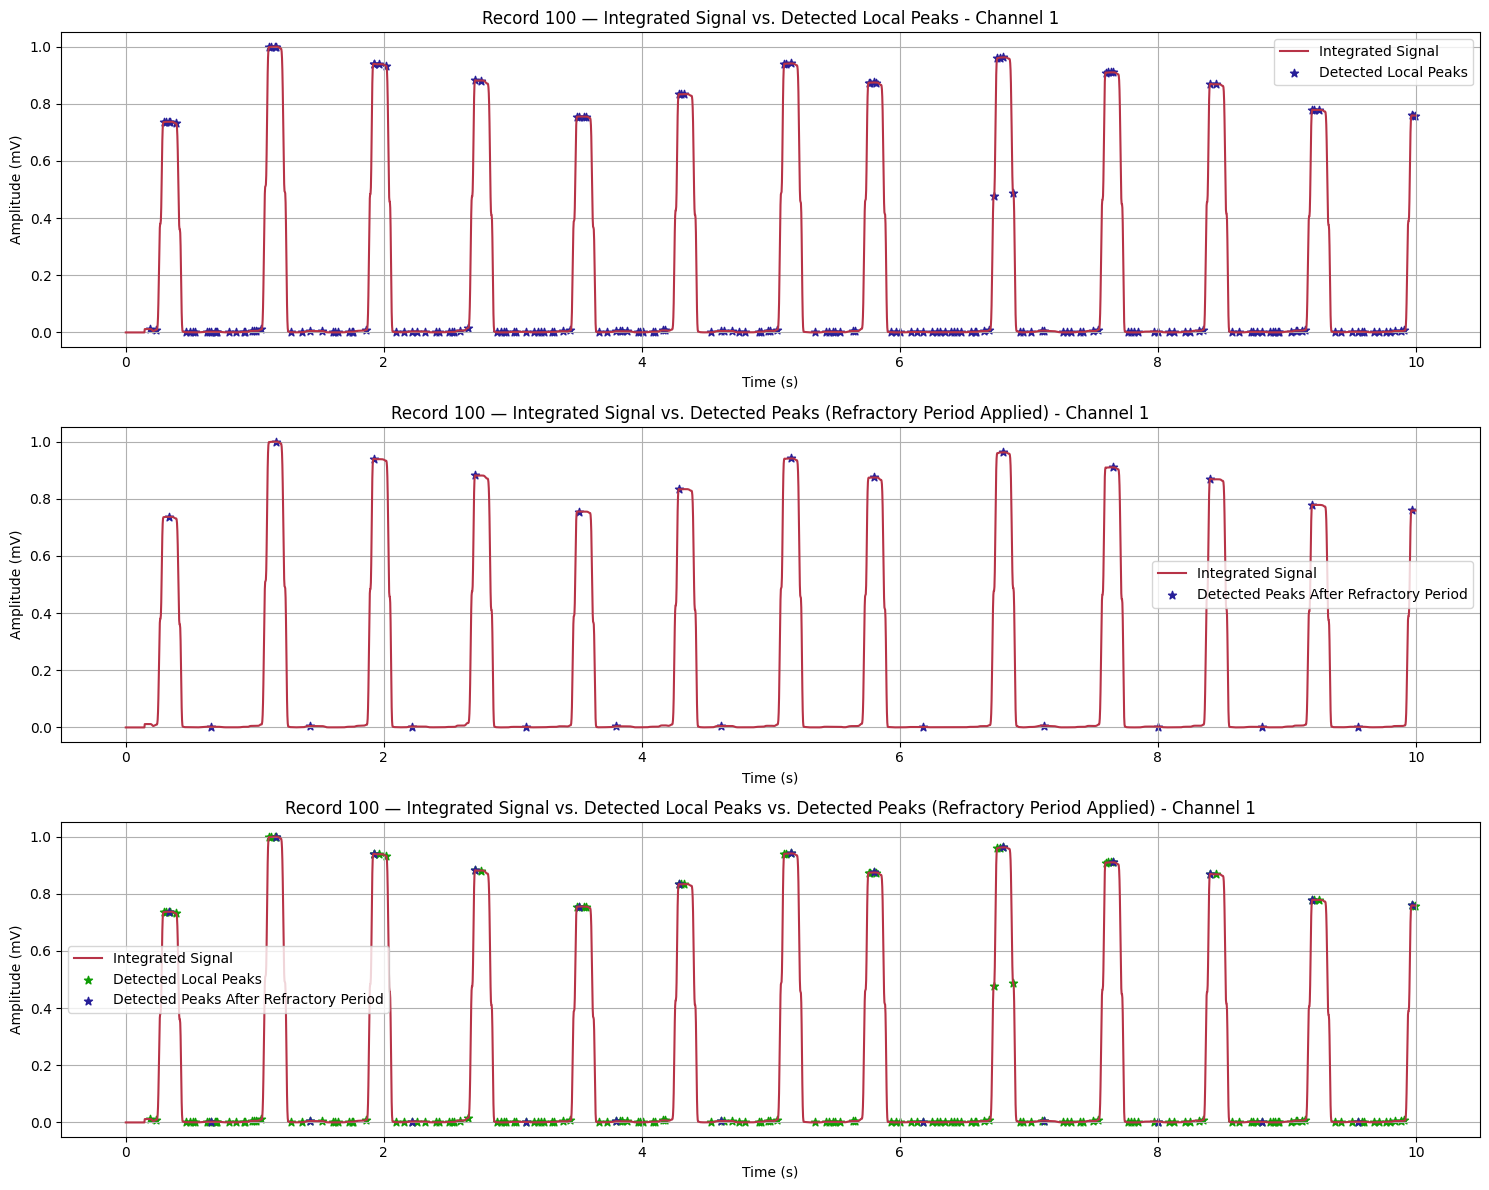

In [26]:
# normalize for plotting
normalized_peaks_int = peaks_int / np.max(np.abs(peaks_int))
normalized_acc_peaks = acc_peaks / np.max(np.abs(acc_peaks))

# Visualize 
plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[peaks_int_indices], normalized_peaks_int, color="#261e98", marker="*", label="Detected Local Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal vs. Detected Local Peaks - Channel 1")
plt.legend()
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[acc_indices], normalized_acc_peaks, color="#261e98", marker="*", label="Detected Peaks After Refractory Period")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal vs. Detected Peaks (Refractory Period Applied) - Channel 1")
plt.legend()
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[peaks_int_indices], normalized_peaks_int, color="#0e9c04", marker="*", label="Detected Local Peaks")
plt.scatter(time[acc_indices], normalized_acc_peaks, color="#261e98", marker="*", label="Detected Peaks After Refractory Period")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal vs. Detected Local Peaks vs. Detected Peaks (Refractory Period Applied) - Channel 1")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 9. Adaptive Threshold Offline (Integrated / Filtered)

In [27]:

def adaptive_threshold_offline(signal, peaks, peaks_indices, fs:float):
    """
    Classify detected ECG peaks using adaptive signal and noise peak estimates.

    This method is generalizable to both moving-window integrated ECG signals
    and band-pass-filtered ECG signals. It initializes signal and noise peak
    estimates from the first two seconds of the input signal, updates these
    estimates using detected local peaks, and computes primary and secondary
    adaptive thresholds. The detected peaks are then classified as signal or
    noise peaks according to the primary threshold.

    Parameters
    ----------
    signal : array_like
        Input ECG signal used to initialize the adaptive signal and noise
        peak estimates. This may be a moving-window integrated signal or
        a band-pass-filtered ECG signal.
    peaks : array_like
        Amplitudes of the detected local peaks in `signal`.
    peaks_indices : array_like
        Sample indices corresponding to `peaks`.
    fs : float
        Sampling frequency of `signal` in Hz.

    Returns
    -------
    threshold_1 : float
        Primary adaptive threshold calculated from the final signal and
        noise peak estimates.
    threshold_2 : float
        Secondary adaptive threshold, calculated as half of `threshold_1`.
    spk : float
        Final signal peak estimate.
    npk : float
        Final noise peak estimate.
    classified_sig_peaks : list
        Peaks classified as signal peaks.
    classified_noise_peaks : list
        Peaks classified as noise peaks.
    classified_sig_pks_indices : list
        Sample indices corresponding to the classified signal peaks.
    classified_noise_pks_indices : list
        Sample indices corresponding to the classified noise peaks.

    Notes
    -----
    The adaptive signal and noise peak estimates use the weighting scheme
    associated with the Pan-Tompkins QRS detection algorithm. The method
    provides an adaptive peak-classification stage and does not implement
    the complete Pan-Tompkins decision logic, including search-back and
    subsequent R-peak localization.

    The estimates and thresholds are updated according to:

        SPK[n] = 0.125 PEAK[n] + 0.875 SPK[n - 1]

        NPK[n] = 0.125 PEAK[n] + 0.875 NPK[n - 1]

        THRESHOLD_1 = NPK + 0.25(SPK - NPK)

        THRESHOLD_2 = 0.5 THRESHOLD_1

    See Also
    --------
    detect_peaks
        Detects local peaks in the input ECG signal.
    refractory_period
        Applies a minimum separation between accepted peak candidates.
    """

    # First 2 seconds of the `integrated signal` or `filtered signal`
    initial_signal = signal[:int(2 * fs)]

    # Initialize signal peak estimate (SPK) --> SPKI0​ = 0.25 Xmax(Xint​)
    SPK = 0.25 * max(initial_signal)
    # Intialize noise peak estimate (NPK) --> NPK0 ​= 0.5 Xmean(Xint​)
    NPK = 0.5 * np.mean(initial_signal) 
    # Initialize threshold 1
    THRESHOLD_1 = NPK + 0.25 * (SPK - NPK)

    # Learning stage
    for peak in peaks:
        # Compare current peak with threshold
        if peak > THRESHOLD_1:
            # update SPK
            SPK = 0.125 * peak + 0.875 * SPK
        else:
            # update NPK
            NPK = 0.125 * peak + 0.875 * NPK

        # Update threshold 1
        THRESHOLD_1 = NPK + 0.25 * (SPK - NPK)

    # Calculate threshold 2
    THRESHOLD_2 = 0.5 * THRESHOLD_1

    # Initialize classiffied signal peaks & niose peaks and their indices
    classified_sig_peaks, classified_noise_peaks = ([] for i in range(2))
    classified_sig_pks_indices, classified_noise_pks_indices = ([] for i in range(2))

    # Classify signal peaks & noise peaks
    for i in range(len(peaks)):
        if peaks[i] > THRESHOLD_1:
            classified_sig_peaks.append(peaks[i])
            classified_sig_pks_indices.append(peaks_indices[i])
        else:
            classified_noise_peaks.append(peaks[i])
            classified_noise_pks_indices.append(peaks_indices[i])

    
    return (
        THRESHOLD_1, THRESHOLD_2, SPK, NPK,
        classified_sig_peaks, classified_noise_peaks,
        classified_sig_pks_indices, classified_noise_pks_indices
    )


In [28]:
ada_thre_output_int = adaptive_threshold_offline(integrated_signal, peaks_int, peaks_int_indices, fs)
ada_thre_output_filt = adaptive_threshold_offline(filtered_signal, peaks_filt, peaks_filt_indices, fs)

In [29]:
thre1_int, thre2_int = ada_thre_output_int[0:2]    # Thresholds I
thre1_filt, thre2_filt = ada_thre_output_filt[0:2]    # Thresholds F
(thre1_int, thre2_int, thre1_filt, thre2_filt)

(np.float64(45217358.21545496),
 np.float64(22608679.10772748),
 np.float64(-63.381803842045116),
 np.float64(-31.690901921022558))

In [30]:
ada_thre_output_int[2:4]     # SPKI & NPKI

(np.float64(178573485.43974984), np.float64(765315.8073566614))

In [31]:
ada_thre_output_filt[2:4]    # SPKF & NPKF

(np.float64(268.71108769508095), np.float64(-174.07943435442047))

In [32]:
csp_int = ada_thre_output_int[4]            # classified signal peaks I
csp_int_indices = ada_thre_output_int[6]    # classified signal peaks indices I
csp_filt = ada_thre_output_filt[4]            # classified signal peaks F
csp_filt_indices = ada_thre_output_filt[6]    # classified signal peaks indices F
csp_int[:5], csp_filt[:5]

([np.float64(162648049.81406224),
  np.float64(162901512.0009373),
  np.float64(162991783.8815623),
  np.float64(162989333.9399998),
  np.float64(161755649.93249986)],
 [np.float64(2.574999999999995),
  np.float64(2.6499999999999835),
  np.float64(302.9950000000178),
  np.float64(386.1750000002447),
  np.float64(327.4450000005331)])

In [33]:
cnp_int = ada_thre_output_int[5]            # classified noise peaks I
cnp_int_indices = ada_thre_output_int[7]    # classified noise peaks indices I
cnp_filt = ada_thre_output_filt[5]            # classified noise peaks F
cnp_filt_indices = ada_thre_output_filt[7]    # classified noise peaks indices F
cnp_int[:5], cnp_filt[:5]

([np.float64(2654207.5378124267),
  np.float64(2152322.218124813),
  np.float64(217330.338749886),
  np.float64(88656.82031243722),
  np.float64(87335.68781241555)],
 [np.float64(-78.06999999999972),
  np.float64(-95.18499999999827),
  np.float64(-161.48499999999183),
  np.float64(-171.46499999997363),
  np.float64(-192.18999999996484)])

In [34]:
(len(csp_int), len(cnp_int)), (len(csp_filt), len(cnp_filt)) # Size 

((46, 162), (15, 294))

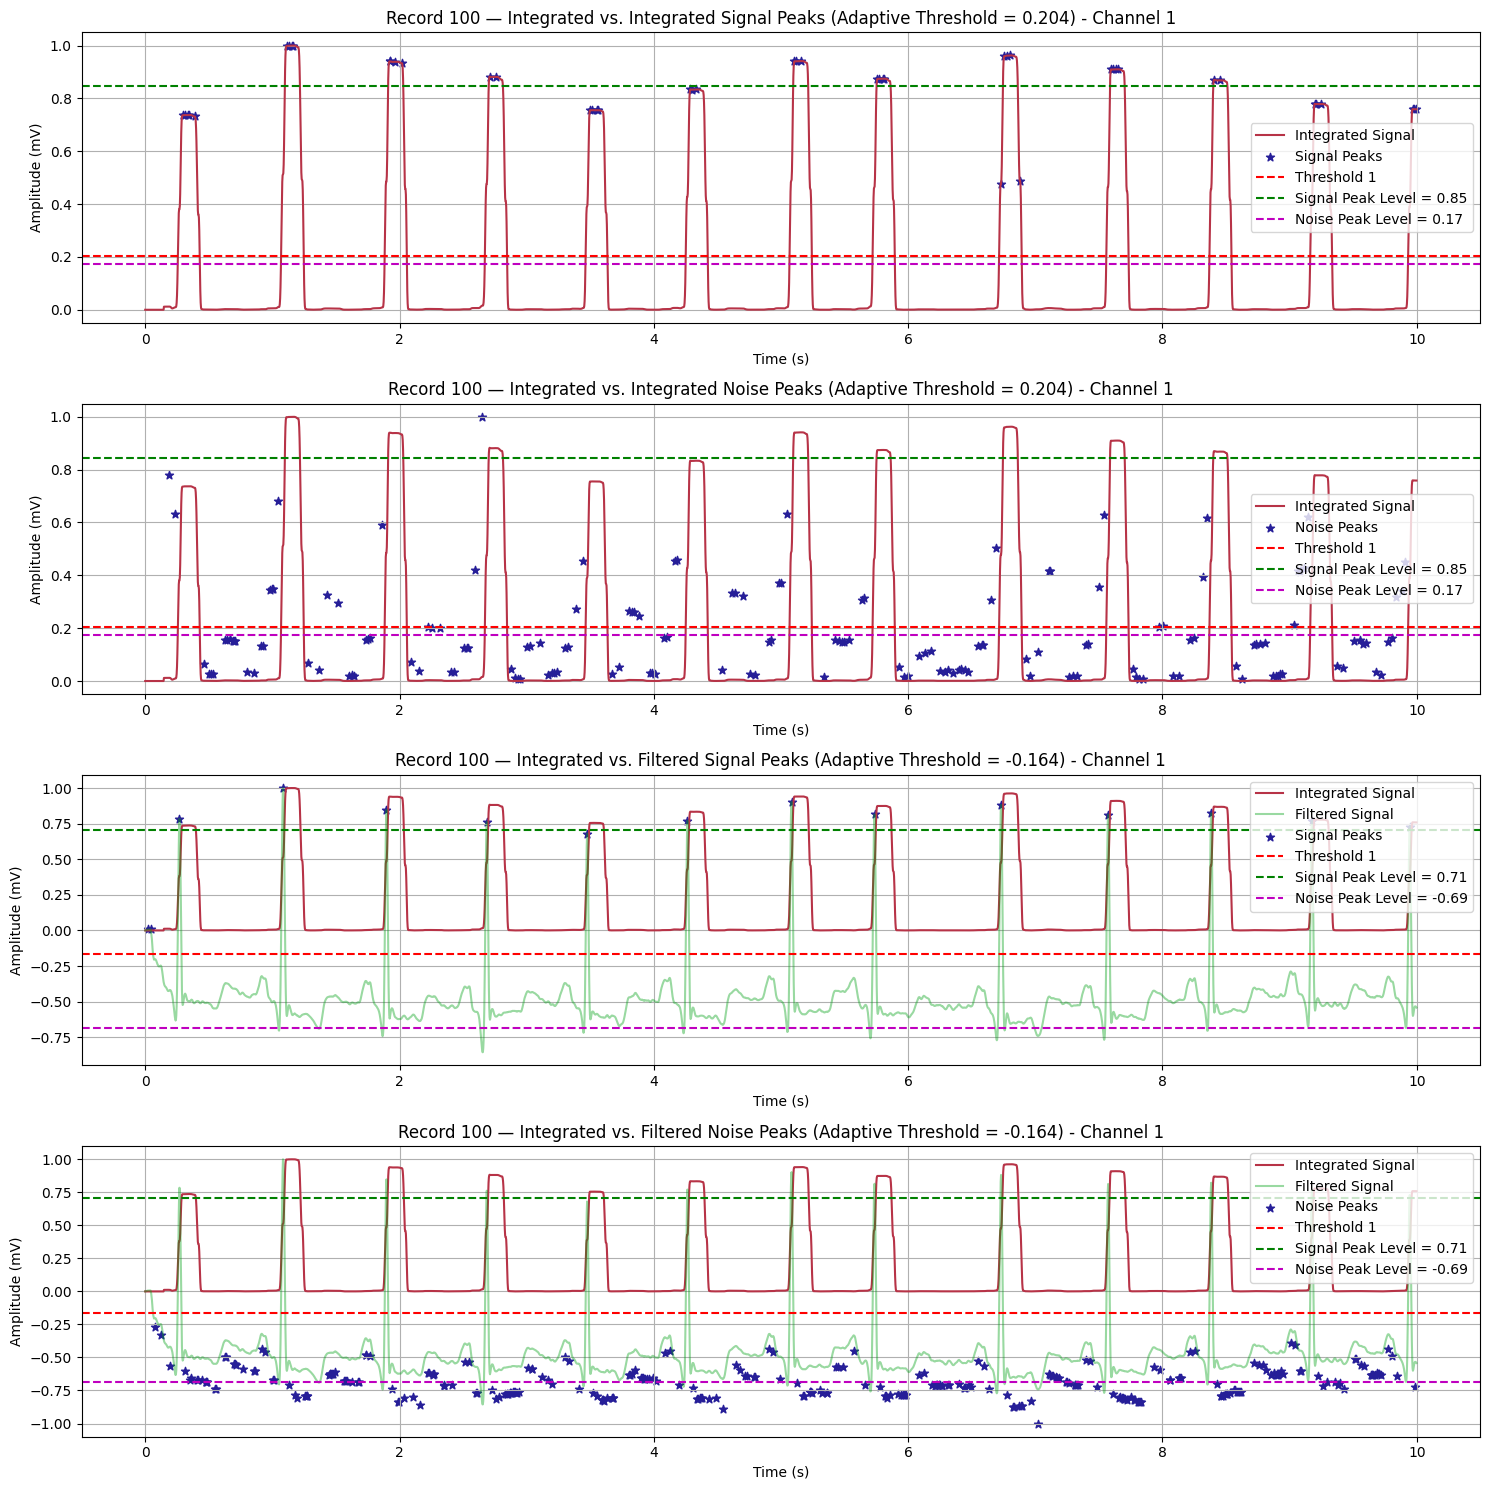

In [35]:
# Normalize for plotting
variables = [csp_int, csp_filt, cnp_int, cnp_filt]

normalized_vals = [v / np.max(np.abs(v)) for v in variables] + [thre1_int / np.max(np.abs(csp_int)),
                                                                 thre1_filt / np.max(np.abs(csp_filt))]

(normalized_csp_int, normalized_csp_filt, normalized_cnp_int,
    normalized_cnp_filt, normalized_thre1_int, normalized_thre1_filt) = normalized_vals

# Calculate mean of peaks
# Integrated
sig_peaks_int_mean = np.mean(normalized_csp_int)
nis_peaks_int_mean = np.mean(normalized_cnp_int)
# Filtered
sig_peaks_filt_mean = np.mean(normalized_csp_filt)
nis_peaks_filt_mean = np.mean(normalized_cnp_filt)

# Visualize 
plt.figure(figsize=(15, 15))

# Integrated signal
#-------------------
plt.subplot(4, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[csp_int_indices], normalized_csp_int, color="#261e98", marker="*", label="Signal Peaks")
plt.axhline(normalized_thre1_int, linestyle="--", color="r", label="Threshold 1")
plt.axhline(sig_peaks_int_mean, linestyle="--", color="g", label=f"Signal Peak Level = {sig_peaks_int_mean:.2f}")
plt.axhline(nis_peaks_int_mean, linestyle="--", color="m", label=f"Noise Peak Level = {nis_peaks_int_mean:.2f}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. Integrated Signal Peaks (Adaptive Threshold = {normalized_thre1_int:.3f}) - Channel 1")
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[cnp_int_indices], normalized_cnp_int, color="#261e98", marker="*", label="Noise Peaks")
plt.axhline(normalized_thre1_int, linestyle="--", color="r", label="Threshold 1")
plt.axhline(sig_peaks_int_mean, linestyle="--", color="g", label=f"Signal Peak Level = {sig_peaks_int_mean:.2f}")
plt.axhline(nis_peaks_int_mean, linestyle="--", color="m", label=f"Noise Peak Level = {nis_peaks_int_mean:.2f}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. Integrated Noise Peaks (Adaptive Threshold = {normalized_thre1_int:.3f}) - Channel 1")
plt.legend()
plt.grid()

# Filtered signal
#-------------------
plt.subplot(4, 1, 3)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#00a015", alpha=0.4, label="Filtered Signal")
plt.scatter(time[csp_filt_indices], normalized_csp_filt, color="#261e98", marker="*", label="Signal Peaks")
plt.axhline(normalized_thre1_filt, linestyle="--", color="r", label="Threshold 1")
plt.axhline(sig_peaks_filt_mean, linestyle="--", color="g", label=f"Signal Peak Level = {sig_peaks_filt_mean:.2f}")
plt.axhline(nis_peaks_filt_mean, linestyle="--", color="m", label=f"Noise Peak Level = {nis_peaks_filt_mean:.2f}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. Filtered Signal Peaks (Adaptive Threshold = {normalized_thre1_filt:.3f}) - Channel 1")
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#00a015", alpha=0.4, label="Filtered Signal")
plt.scatter(time[cnp_filt_indices], normalized_cnp_filt, color="#261e98", marker="*", label="Noise Peaks")
plt.axhline(normalized_thre1_filt, linestyle="--", color="r", label="Threshold 1")
plt.axhline(sig_peaks_filt_mean, linestyle="--", color="g", label=f"Signal Peak Level = {sig_peaks_filt_mean:.2f}")
plt.axhline(nis_peaks_filt_mean, linestyle="--", color="m", label=f"Noise Peak Level = {nis_peaks_filt_mean:.2f}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. Filtered Noise Peaks (Adaptive Threshold = {normalized_thre1_filt:.3f}) - Channel 1")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### - Apply Refractory Period on the Result of `adaptive_threshold_offline`

In [36]:
acc_cls_sig_pks_int, acc_cls_sig_ids_int = refractory_period(normalized_csp_int, csp_int_indices, fs)
acc_cls_sig_pks_filt, acc_cls_sig_ids_filt = refractory_period(normalized_csp_filt, csp_filt_indices, fs)

In [37]:
((len(acc_cls_sig_pks_int), len(acc_cls_sig_ids_int)),    # Count of the actual Integrated signal peaks 
(len(acc_cls_sig_pks_filt), len(acc_cls_sig_ids_filt)))    # Count of the actual Filtered signal peaks 

((13, 13), (14, 14))

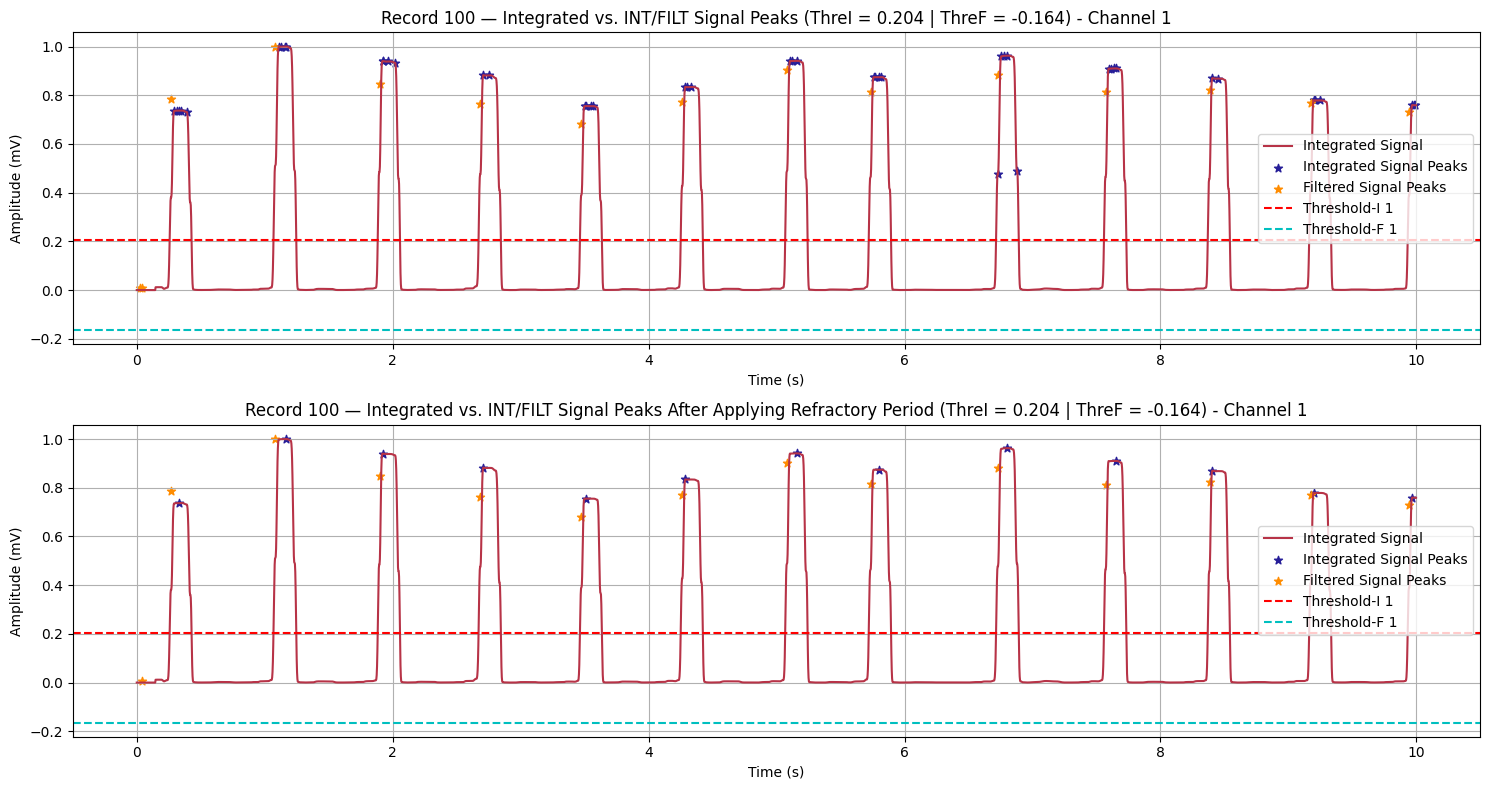

In [38]:
# Calculate mean of peaks
sig_pks_ref_int_mean = np.mean(acc_cls_sig_pks_int)
sig_pks_ref_filt_mean = np.mean(acc_cls_sig_pks_filt)

# Visualize 
plt.figure(figsize=(15, 8))

# Integrated signal
#-------------------
plt.subplot(2, 1, 1)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[csp_int_indices], normalized_csp_int, color="#261e98", marker="*", label="Integrated Signal Peaks")
plt.scatter(time[csp_filt_indices], normalized_csp_filt, color="#ff8c00", marker="*", label="Filtered Signal Peaks")
plt.axhline(normalized_thre1_int, linestyle="--", color="r", label="Threshold-I 1")
plt.axhline(normalized_thre1_filt, linestyle="--", color="c", label="Threshold-F 1")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. INT/FILT Signal Peaks (ThreI = {normalized_thre1_int:.3f} | ThreF = {normalized_thre1_filt:.3f}) - Channel 1")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter(time[acc_cls_sig_ids_int], acc_cls_sig_pks_int, color="#261e98", marker="*", label="Integrated Signal Peaks")
plt.scatter(time[acc_cls_sig_ids_filt], acc_cls_sig_pks_filt, color="#ff8c00", marker="*", label="Filtered Signal Peaks")
plt.axhline(normalized_thre1_int, linestyle="--", color="r", label="Threshold-I 1")
plt.axhline(normalized_thre1_filt, linestyle="--", color="c", label="Threshold-F 1")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. INT/FILT Signal Peaks After Applying Refractory Period (ThreI = {normalized_thre1_int:.3f} | ThreF = {normalized_thre1_filt:.3f}) - Channel 1")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 10. R-Peaks Localization

In [ ]:
# search area = candidate index ± search window (0.15 . fs)
def localize_r_peaks(signal, integrated_indices, fs:float, search_window:None=None):
    """
    Localize R-peaks in an ECG signal around candidate QRS locations.

    For each candidate index obtained from the moving-window integrated
    signal, searches a symmetric region of the input ECG signal and
    identifies the sample with the maximum amplitude as the corresponding
    R-peak. If `search_window` is not specified, a default half-window of
    150 ms is used.

    Parameters
    ----------
    signal : array_like
        ECG signal in which the R-peaks are to be localized.
    integrated_indices : array_like
        Sample indices of candidate QRS peaks detected from the
        moving-window integrated signal.
    fs : float
        Sampling frequency of the ECG signal in Hz.
    search_window : float or None, optional
        Search-window half-width in samples. If None, the half-width is
        set to 0.15 * fs, corresponding to 150 ms.

    Returns
    -------
    localized_r_peaks : list
        Amplitudes of the localized R-peaks.
    localized_r_peaks_indices : list
        Sample indices corresponding to the localized R-peaks.

    Notes
    -----
    The search is performed around each candidate index using the range

        [candidate_index - search_window,
         candidate_index + search_window]

    The sample with the maximum amplitude within each search region is
    selected as the localized R-peak.
    """

    # Check search window for any specific value
    if search_window == None:
        # Calculate search window
        search_window = int(0.15 * fs)

    # initialize a list to store localized r peaks 
    #   & it correspoding indices
    localized_r_peaks = []
    localized_r_peaks_indices = []

    for i in integrated_indices:
        # Calculate lower- and upper- bounds
        lowerbound = max(0, int(i - search_window))
        upperbound = min(len(signal), int(i + search_window))

        # Get the maximum amplitude in the area
        area = signal[lowerbound:upperbound]

        # Get indices
        local_index = np.argmax(area)
        global_index = lowerbound + local_index

        # Collect r peaks
        localized_r_peaks.append(signal[global_index])

        # Collect r peaks indices
        localized_r_peaks_indices.append(global_index)

    return localized_r_peaks, localized_r_peaks_indices


In [40]:
localized_r_pks, localized_r_pks_ids = localize_r_peaks(filtered_signal, acc_cls_sig_ids_int, fs)
localized_r_pks, localized_r_pks_ids

([np.float64(302.9950000000178),
  np.float64(386.1750000002447),
  np.float64(327.4450000005331),
  np.float64(294.30500000082407),
  np.float64(262.81500000087453),
  np.float64(297.6700000009058),
  np.float64(348.7350000011722),
  np.float64(314.68500000149174),
  np.float64(340.4050000019435),
  np.float64(313.9000000024797),
  np.float64(317.68500000301776),
  np.float64(297.1750000032818),
  np.float64(281.86000000339743)],
 [np.int64(97),
  np.int64(390),
  np.int64(683),
  np.int64(967),
  np.int64(1251),
  np.int64(1535),
  np.int64(1830),
  np.int64(2065),
  np.int64(2423),
  np.int64(2726),
  np.int64(3018),
  np.int64(3303),
  np.int64(3580)])

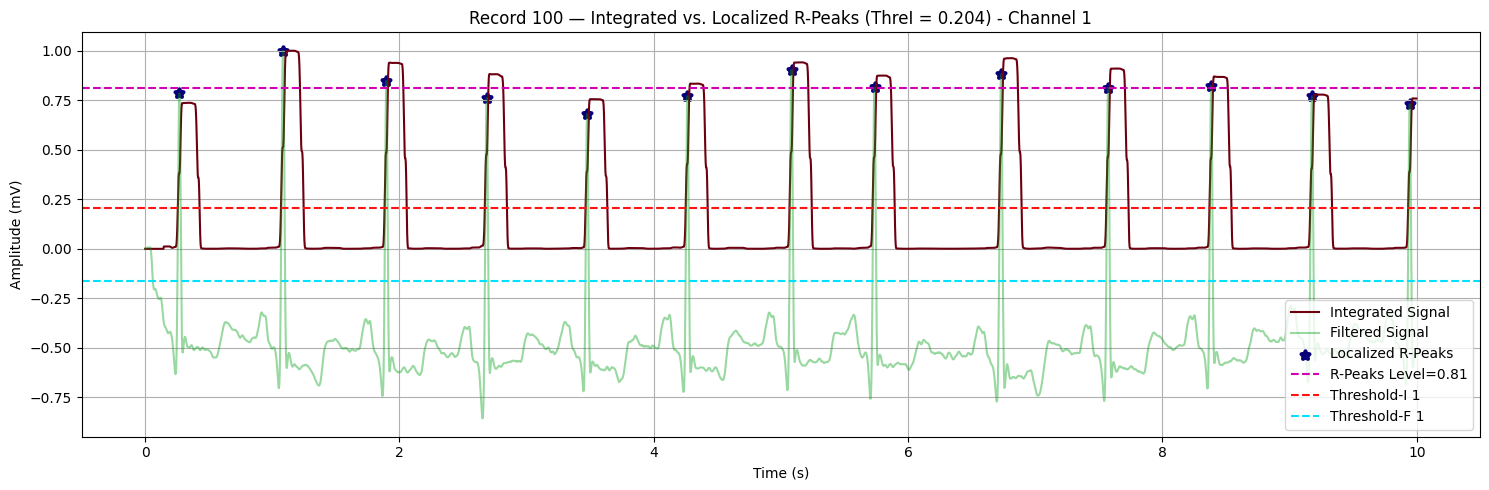

In [41]:
# Normalize for plotting
normalized_localized_r_pks = localized_r_pks / np.max(np.abs(localized_r_pks))

# Calculate r peaks level
r_peaks_mean = np.mean(normalized_localized_r_pks)

# Visualize 
plt.figure(figsize=(15, 5))

plt.plot(time[:n_samples_to_plot], normalized_integrated, color="#6d0010", label="Integrated Signal")
plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#00a015", alpha=0.4, label="Filtered Signal")
plt.scatter(time[localized_r_pks_ids], normalized_localized_r_pks, color="#080079", marker="*", linewidth=3, label="Localized R-Peaks")
plt.axhline(r_peaks_mean, linestyle="--", color="#d100b5", label=f"R-Peaks Level={r_peaks_mean:.2f}")
plt.axhline(normalized_thre1_int, linestyle="--", color="#ff1212", label="Threshold-I 1")
plt.axhline(normalized_thre1_filt, linestyle="--", color="#00e1ff", label="Threshold-F 1")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 — Integrated vs. Localized R-Peaks (ThreI = {normalized_thre1_int:.3f}) - Channel 1")
plt.legend(loc="lower right")
plt.grid()

plt.tight_layout()
plt.show()

## 11. Search Back Offline

In [43]:
# RR_current > 1.66 × RR_average
def search_back_offline(
    accepted_peaks,
    accepted_indices,
    noise_peaks,
    noise_indices,
    threshold_2
):
    """
    Recover potentially missed QRS complexes from rejected peak candidates
    when an unusually long RR interval is detected.

    The method examines consecutive accepted R-peak detections and compares
    each current RR interval with the average RR interval. If an RR interval
    exceeds 1.66 times the current average RR interval, the corresponding
    interval is considered suspicious. Rejected peak candidates within that
    interval are then examined, and candidates exceeding the secondary
    adaptive threshold are considered for recovery. If multiple eligible
    candidates exist, the candidate with the greatest amplitude is selected
    and inserted into the accepted detections.

    Parameters
    ----------
    accepted_peaks : array_like
        Amplitudes of the currently accepted R-peak candidates.
    accepted_indices : array_like
        Sample indices corresponding to `accepted_peaks`. The indices must
        be ordered chronologically.
    noise_peaks : array_like
        Amplitudes of peak candidates previously classified as noise.
    noise_indices : array_like
        Sample indices corresponding to `noise_peaks`.
    threshold_2 : float
        Secondary adaptive threshold used to determine whether a rejected
        peak is sufficiently strong to be reconsidered as a QRS candidate.

    Returns
    -------
    updated_peaks : list
        Accepted R-peak amplitudes after search-back recovery.
    updated_indices : list
        Sample indices corresponding to `updated_peaks`, ordered
        chronologically.

    Notes
    -----
    An RR interval is considered suspicious when:

        RR_current > 1.66 * RR_average

    For a suspicious interval, rejected candidates located between the two
    surrounding accepted R-peaks are examined. Only candidates exceeding
    `threshold_2` are considered, and the strongest eligible candidate is
    recovered.
    """

    # Copy accepted detections
    updated_peaks = list(accepted_peaks)
    updated_indices = list(accepted_indices)

    # Calculate initial RR intervals
    rr_intervals = [
        updated_indices[i] - updated_indices[i - 1]
        for i in range(1, len(updated_indices))
    ]

    # Need at least two RR intervals
    if len(rr_intervals) < 2:
        return updated_peaks, updated_indices

    # Initial average RR interval
    rr_average = np.mean(rr_intervals)

    i = 0

    while i < len(updated_indices) - 1:

        # Current RR interval
        rr_current = updated_indices[i + 1] - updated_indices[i]

        # Check for unusually long RR interval
        if rr_current > 1.66 * rr_average:

            lower_bound = updated_indices[i]
            upper_bound = updated_indices[i + 1]

            # Find eligible rejected candidates inside the interval
            candidates = [
                (peak, index)
                for peak, index in zip(noise_peaks, noise_indices)
                if lower_bound < index < upper_bound
                and peak > threshold_2
            ]

            if candidates:

                # Select strongest candidate
                recovered_peak, recovered_index = max(
                    candidates,
                    key=lambda candidate: candidate[0]
                )

                # Insert recovered QRS chronologically
                updated_peaks.insert(i + 1, recovered_peak)
                updated_indices.insert(i + 1, recovered_index)

                # Recalculate RR intervals
                rr_intervals = [
                    updated_indices[j] - updated_indices[j - 1]
                    for j in range(1, len(updated_indices))
                ]

                rr_average = np.mean(rr_intervals)

        i += 1

    return updated_peaks, updated_indices


In [47]:
updated_peaks, updated_indices = search_back_offline(localized_r_pks, localized_r_pks_ids, cnp_int, cnp_int_indices, thre2_int)

In [48]:
updated_peaks

[np.float64(302.9950000000178),
 np.float64(386.1750000002447),
 np.float64(327.4450000005331),
 np.float64(294.30500000082407),
 np.float64(262.81500000087453),
 np.float64(297.6700000009058),
 np.float64(348.7350000011722),
 np.float64(314.68500000149174),
 np.float64(340.4050000019435),
 np.float64(313.9000000024797),
 np.float64(317.68500000301776),
 np.float64(297.1750000032818),
 np.float64(281.86000000339743)]

In [49]:
updated_indices

[np.int64(97),
 np.int64(390),
 np.int64(683),
 np.int64(967),
 np.int64(1251),
 np.int64(1535),
 np.int64(1830),
 np.int64(2065),
 np.int64(2423),
 np.int64(2726),
 np.int64(3018),
 np.int64(3303),
 np.int64(3580)]

> By looking at the results we can infer that there are no missed r-peaks in the accepted r-peaks.

### - Compare the detected R-peaks of the filtered ECG with the original ECG and its peaks annotations 

In [52]:
# Loaf the annotations
annotations = wfdb.rdann(str(MITDB_DIR / "100"), "atr")

In [53]:
# Inspect
print("Number of annotations:", len(annotations.sample))
print("Annotation symbols:", np.unique(annotations.symbol))

Number of annotations: 2274
Annotation symbols: ['+' 'A' 'N' 'V']


In [56]:
# Get annotations within n number of samples (samples = 3600 as previous calculations for 10 sec segment)
mask = annotations.sample < n_samples_to_plot
annotation_samples = annotations.sample[mask]
# Convert to time
annotation_times = annotation_samples / record.fs
annotation_symbols = [symbol for symbol, selected in zip(annotations.symbol, mask) if selected]


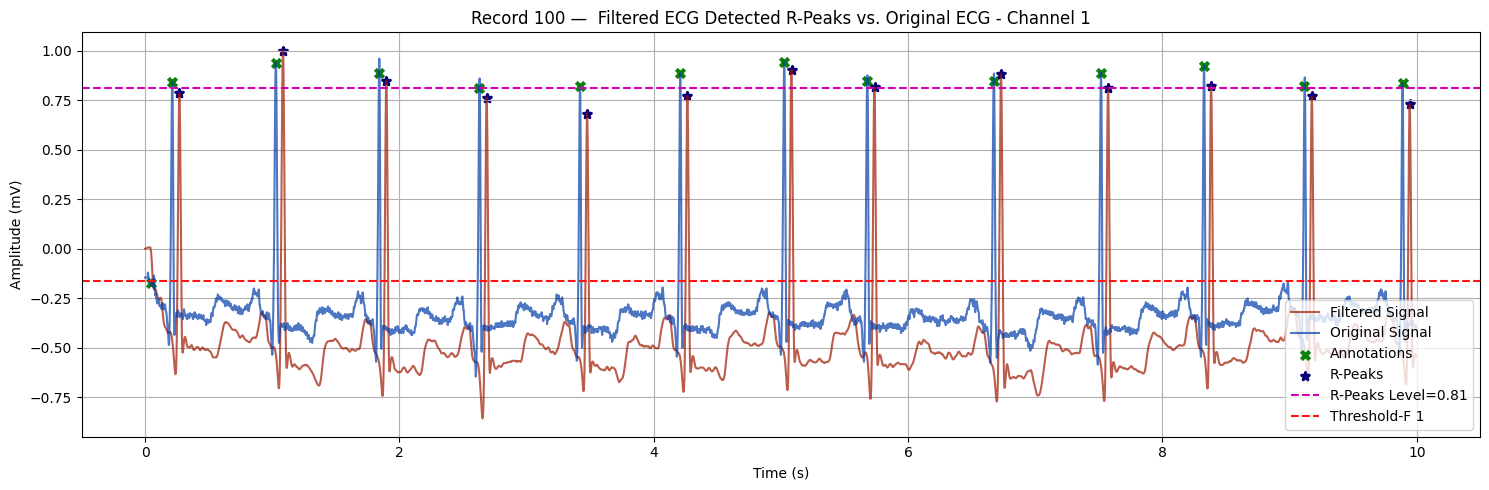

In [67]:
# Normalize for plotting
normalized_updated_peaks = updated_peaks / np.max(np.abs(updated_peaks))

# Calculate r peaks level
r_peaks_mean_up = np.mean(normalized_updated_peaks)

# Visualize 
plt.figure(figsize=(15, 5))

plt.plot(time[:n_samples_to_plot], normalized_filtered, color="#a01800", alpha=0.7, label="Filtered Signal")
plt.plot(time[:n_samples_to_plot], ten_seg_sig, color="#013caa", alpha=0.7, label="Original Signal")
plt.scatter(annotation_times, record.p_signal[annotation_samples, 0], marker="x", c="#0e800e", linewidth=3, label="Annotations")
plt.scatter(time[updated_indices], normalized_updated_peaks, color="#080079", marker="*", linewidth=2, label="R-Peaks")
plt.axhline(r_peaks_mean_up, linestyle="--", color="#d100b5", label=f"R-Peaks Level={r_peaks_mean_up:.2f}")
plt.axhline(normalized_thre1_filt, linestyle="--", color="#ff1212", label="Threshold-F 1")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record 100 —  Filtered ECG Detected R-Peaks vs. Original ECG - Channel 1")
plt.legend(loc="lower right")
plt.grid()

plt.tight_layout()
plt.show()